# Yelp Polarity Sentiment — Mean-Embedding Baseline

Yelp Polarity binary sentiment classification using a trainable embedding layer and the architecture defined below.


## 2.1 Data Preprocessing — Setup

In [48]:
%pip -q install datasets scikit-learn seaborn psutil


In [49]:
import os
import re
import time
import random
import platform
import resource
import json
from pathlib import Path

# Create a separate run folder for this model.
BASE_DIR = Path(os.environ.get("TASK2_RUN_DIR", "/content/sample_data/TASK2_RUN_DIR")).resolve()
RUN_DIR = BASE_DIR / "mean_embedding"
SRC_DIR = RUN_DIR / "src"
DATA_PROCESSED_DIR = RUN_DIR / "data_processed"
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
OUTPUT_DIR = RUN_DIR / "outputs"
METRICS_REPORT_PATH = RUN_DIR / "metrics_report.csv"
FAILURE_ANALYSIS_PATH = RUN_DIR / "failure_analysis.md"
RESULTS_PATH = RUN_DIR / "results.md"

for folder in (RUN_DIR, SRC_DIR, DATA_PROCESSED_DIR, CHECKPOINT_DIR, OUTPUT_DIR):
    folder.mkdir(parents=True, exist_ok=True)

if not FAILURE_ANALYSIS_PATH.exists():
    FAILURE_ANALYSIS_PATH.write_text(
        "# Failure Analysis\n\nComplete this file after reviewing the exported manual-error CSV.\n",
        encoding="utf-8"
    )
if not RESULTS_PATH.exists():
    RESULTS_PATH.write_text(
        "# Model Results\n\nThis file is populated after the training run.\n",
        encoding="utf-8"
    )
print("Run directory:", RUN_DIR)
print("Created folders:", DATA_PROCESSED_DIR, OUTPUT_DIR, CHECKPOINT_DIR)
RUN_LOG_PATH = RUN_DIR / "RUN_LOG.txt"
RUN_LOG_PATH.touch(exist_ok=True)

def write_run_log(message):
    message = str(message)
    with RUN_LOG_PATH.open("a", encoding="utf-8") as log_file:
        log_file.write(message + "\n")
        log_file.flush()
    print(message, flush=True)

run_stamp = time.strftime("%Y-%m-%d %H:%M:%S")
write_run_log(f"\n===== baseline_mean_embedding run started: {run_stamp} =====")
print("RUN_LOG_PATH:", RUN_LOG_PATH)
print("METRICS_MD_PATH:", RUN_DIR / "metrics.md")
print("Outputs:", OUTPUT_DIR)
print("Checkpoints:", CHECKPOINT_DIR)


Run directory: /content/sample_data/TASK2_RUN_DIR/mean_embedding
Created folders: /content/sample_data/TASK2_RUN_DIR/mean_embedding/data_processed /content/sample_data/TASK2_RUN_DIR/mean_embedding/outputs /content/sample_data/TASK2_RUN_DIR/mean_embedding/checkpoints

===== baseline_mean_embedding run started: 2026-10-03 20:11:46 =====
RUN_LOG_PATH: /content/sample_data/TASK2_RUN_DIR/mean_embedding/RUN_LOG.txt
METRICS_MD_PATH: /content/sample_data/TASK2_RUN_DIR/mean_embedding/metrics.md
Outputs: /content/sample_data/TASK2_RUN_DIR/mean_embedding/outputs
Checkpoints: /content/sample_data/TASK2_RUN_DIR/mean_embedding/checkpoints


In [50]:
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [52]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, average_precision_score,
    matthews_corrcoef, brier_score_loss, f1_score)
from scipy.stats import binom

In [53]:
SID4 = 9002
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

# Shared experiment settings.
MAX_TRAIN = 20_000
MAX_TEST = 5_000
VAL_SIZE = 0.10
MAX_VOCAB = 30_000
MAX_LEN = 180
BATCH_SIZE = 128
EPOCHS = 5
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

print({"SID4": SID4, "SEED": SEED, "SLICE": SLICE, "HP_ID": HP_ID,
       "CLS_A": CLS_A, "CLS_B": CLS_B})
USE_STEMMING = False


{'SID4': 9002, 'SEED': 9002, 'SLICE': 2, 'HP_ID': 2, 'CLS_A': 2, 'CLS_B': 3}


In [54]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything()
print("Device:", DEVICE)
print("Device name:", torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else platform.processor())
print("PyTorch:", torch.__version__)

Device: cpu
Device name: x86_64
PyTorch: 2.11.0+cpu


## 2.1.1 Analyse review length distribution, class distribution, and balance

In [55]:
dataset = load_dataset("fancyzhx/yelp_polarity")
train_raw = pd.DataFrame(dataset["train"])
test_raw = pd.DataFrame(dataset["test"])

print(dataset)
print("Train:", train_raw.shape, "Test:", test_raw.shape)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})
Train: (560000, 2) Test: (38000, 2)


In [56]:
print("\nMissing values:")
print(pd.concat({"train": train_raw.isna().sum(), "test": test_raw.isna().sum()}, axis=1))
print("\nClass counts:")
print(train_raw["label"].value_counts().sort_index())


Missing values:
       train  test
text       0     0
label      0     0

Class counts:
label
0    280000
1    280000
Name: count, dtype: int64


In [57]:
print("\nClass proportions:")
print(train_raw["label"].value_counts(normalize=True).sort_index().round(4))


Class proportions:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [58]:
lengths = train_raw["text"].astype(str).str.split().str.len()
print(lengths.describe(percentiles=[.5, .75, .9, .95, .99]).round(2))

count    560000.00
mean        133.03
std         122.61
min           1.00
50%          97.00
75%         174.00
90%         282.00
95%         372.00
99%         608.00
max        1052.00
Name: text, dtype: float64


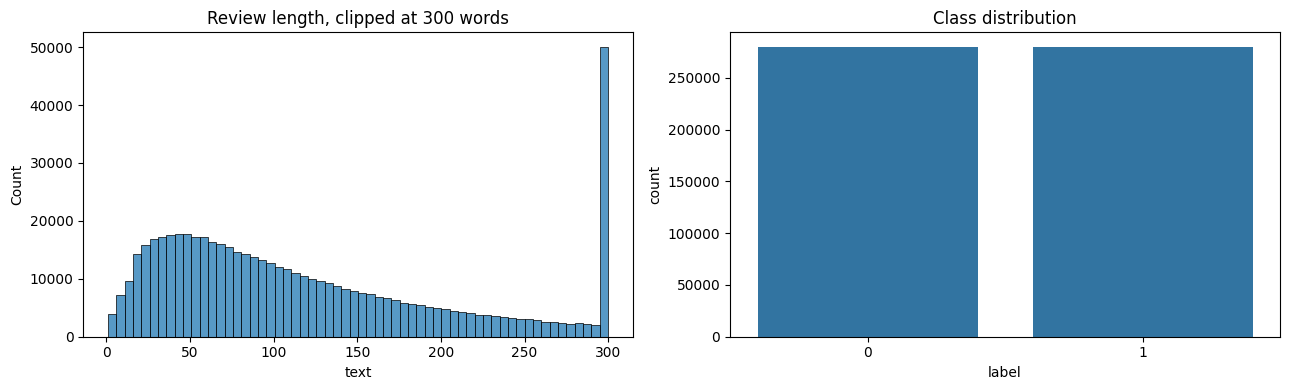

In [59]:
fig, ax= plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(lengths.clip(upper=300), bins=60, ax=ax[0])
ax[0].set_title("Review length, clipped at 300 words")
sns.countplot(data=train_raw, x="label", ax=ax[1])
ax[1].set_title("Class distribution")
plt.tight_layout()

## 2.1.2 Handle missing and malformed entries

Rows with missing text, non-numeric labels, non-binary labels, or empty processed text are removed.

In [60]:
STOPWORDS = {
    "a","an","and","are","as","at","be","but","by","for","from","has","have","he","her",
    "i","if","in","is","it","its","me","my","of","on","or","our","she","so","that","the",
    "their","there","they","this","to","was","we","were","what","when","which","who",
    "will","with","you","your"
    # Retain negation terms because they affect sentiment polarity.
}

## 2.1.3 Lowercase, remove punctuation, stopwords, and stem

In [61]:
def light_stem(token):
    for suffix in ("ingly", "edly", "ing", "ed", "ies", "es", "s"):
        if len(token) > len(suffix) + 3 and token.endswith(suffix):
            return token[:-len(suffix)]
    return token

In [62]:
def tokenize(text):
    text = re.sub(r"[^a-z0-9\s' ]", " ", str(text).lower())
    words = re.findall(r"[a-z0-9]+(?:'[a-z0-9]+)?", text)
    words = [w for w in words if w not in STOPWORDS]
    return [light_stem(w) for w in words] if USE_STEMMING else words

print(tokenize("The food was AMAZING!!! I wouldn't order it again."))

['food', 'amazing', "wouldn't", 'order', 'again']


## 2.1.4 Clean, sample, and split the data

In [63]:
def clean_frame(frame):
    out = frame[["text", "label"]].copy()
    out["text"] = out["text"].fillna("").astype(str)
    out["label"] = pd.to_numeric(out["label"], errors="coerce")
    out = out.dropna(subset=["label"])
    out = out[out["label"].isin([0, 1])]
    out["tokens"] = out["text"].map(tokenize)
    return out[out["tokens"].map(len) > 0].reset_index(drop=True)

In [64]:
train_df = clean_frame(train_raw)
test_df = clean_frame(test_raw)

In [65]:
if MAX_TRAIN is not None:
    train_df, _ = train_test_split(train_df, train_size=MAX_TRAIN,
        stratify=train_df["label"], random_state=SEED)
if MAX_TEST is not None:
    test_df, _ = train_test_split(test_df, train_size=MAX_TEST,
        stratify=test_df["label"], random_state=SEED)

In [66]:
train_df, val_df = train_test_split(train_df.reset_index(drop=True), test_size=VAL_SIZE,
    stratify=train_df["label"], random_state=SEED)
train_df = train_df.reset_index(drop=True); val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [67]:
print("Rows:", len(train_df), "train |", len(val_df), "validation |", len(test_df), "test")

Rows: 18000 train | 2000 validation | 5000 test


In [68]:
print("Rows remaining after cleaning:", len(train_df), "train |", len(val_df), "validation |", len(test_df), "test")
print("Class balance after sampling and split:")
print(pd.DataFrame({"train": train_df["label"].value_counts(normalize=True),
                    "validation": val_df["label"].value_counts(normalize=True),
                    "test": test_df["label"].value_counts(normalize=True)}).sort_index().round(4))

Rows remaining after cleaning: 18000 train | 2000 validation | 5000 test
Class balance after sampling and split:
       train  validation  test
label                         
0        0.5         0.5   0.5
1        0.5         0.5   0.5


## 2.1.5 Tokenise and learn embeddings from scratch

In [69]:
PAD, UNK = "<pad>", "<unk>"
counts = Counter(t for row in train_df["tokens"] for t in row)
vocab_tokens = [PAD, UNK] + [t for t, _ in counts.most_common(MAX_VOCAB - 2)]
stoi = {t: i for i, t in enumerate(vocab_tokens)}
print("Vocabulary size:", len(stoi))
print("Most common:", counts.most_common(15))

Vocabulary size: 30000
Most common: [('n', 26126), ('not', 16335), ('had', 14438), ('food', 10605), ('place', 10363), ('good', 9722), ('out', 8691), ('all', 8609), ('like', 8459), ('just', 8313), ('get', 7842), ('very', 7655), ('one', 7577), ('here', 7365), ('time', 7083)]


In [70]:
def encode(tokens):
    ids = [stoi.get(t, stoi[UNK]) for t in tokens[:MAX_LEN]]
    return ids or [stoi[UNK]]

In [71]:
class ReviewDataset(Dataset):
    def __init__(self, frame):
        self.x = [encode(t) for t in frame["tokens"]]
        self.y = frame["label"].astype(int).to_numpy()
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x[i], int(self.y[i]), i

In [72]:
def collate_batch(batch):
    seqs, ys, ids = zip(*batch)
    batch_len = max(7, max(map(len, seqs)))
    x = torch.full((len(seqs), batch_len), stoi[PAD], dtype=torch.long)
    for r, seq in enumerate(seqs): x[r, :len(seq)] = torch.tensor(seq)
    return x, torch.tensor(ys, dtype=torch.float32), torch.tensor(ids)

In [73]:
def loader(frame, shuffle=False):
    return DataLoader(ReviewDataset(frame), batch_size=BATCH_SIZE, shuffle=shuffle,
        collate_fn=collate_batch, num_workers=0, pin_memory=DEVICE.type == "cuda")

train_loader = loader(train_df, True)
val_loader = loader(val_df)
test_loader = loader(test_df)

## 2.2 Model Training and Evaluation — Architecture justification

### Model lineup

- **Baseline:** learned embeddings with masked mean pooling and a linear classifier.
- **Experimental CNN:** learned embeddings with multiple convolution widths for local phrases.
- **Experimental BiGRU:** learned embeddings with bidirectional sequence context.
- All embeddings are randomly initialized and learned only from the training data.

## 2.2.1 Baseline model

In [74]:
class MeanEmbeddingBaseline(nn.Module):
    def __init__(self, vocab, dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab, dim, padding_idx=stoi[PAD])
        self.classifier = nn.Sequential(nn.Dropout(.20), nn.Linear(dim, 1))
    def forward(self, x):
        mask = (x != stoi[PAD]).unsqueeze(-1)
        h = self.embedding(x)
        pooled = (h * mask).sum(1) / mask.sum(1).clamp_min(1)
        return self.classifier(pooled).squeeze(1)

## 2.2.4 Model factory and parameter counts

In [75]:
model_factories = {
    "baseline_mean_embedding": lambda: MeanEmbeddingBaseline(len(stoi)),
}
for name, make in model_factories.items():
    print(name, parameter_count(make()) if "parameter_count" in globals() else sum(
        p.numel() for p in make().parameters() if p.requires_grad), "parameters")

baseline_mean_embedding 3840129 parameters


## 2.2.5 Training utilities and exact CPU/GPU

In [76]:
def parameter_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [77]:
@torch.no_grad()
def predict(model, data_loader):
    model.eval(); ys, ps, ids = [], [], []
    for x, y, idx in data_loader:
        ps.extend(torch.sigmoid(model(x.to(DEVICE))).cpu().numpy())
        ys.extend(y.numpy()); ids.extend(idx.numpy())
    return np.asarray(ys).astype(int), np.asarray(ps), np.asarray(ids).astype(int)

In [78]:
def train_one(name, make):
    seed_everything()
    model = make().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.BCEWithLogitsLoss()
    history = []
    if DEVICE.type == "cuda": torch.cuda.reset_peak_memory_stats()
    start = time.perf_counter()
    for epoch in range(1, EPOCHS + 1):
        model.train(); total = 0; seen = 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model(x), y); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
            total += loss.item() * len(y); seen += len(y)
        vy, vp, _ = predict(model, val_loader)
        history.append({"model": name, "epoch": epoch, "train_loss": total/seen,
            "val_macro_f1": f1_score(vy, vp >= .5, average="macro")})
        write_run_log(f"{name} | epoch {epoch}/{EPOCHS} | loss {total/seen:.4f} | "
              f"val macro-F1 {history[-1]['val_macro_f1']:.4f}")
    elapsed = time.perf_counter() - start
    vy, vp, _ = predict(model, val_loader)
    thresholds = np.linspace(.20, .80, 61)
    threshold = max(thresholds, key=lambda t: f1_score(vy, vp >= t, average="macro"))
    y, p, ids = predict(model, test_loader)
    peak = (torch.cuda.max_memory_allocated() / 2**20 if DEVICE.type == "cuda"
            else resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024)
    cpu_name = platform.processor()
    if not cpu_name:
        try:
            with open("/proc/cpuinfo", encoding="utf-8") as f:
                cpu_name = next((line.split(":", 1)[1].strip() for line in f
                    if line.lower().startswith("model name")), platform.machine())
        except OSError:
            cpu_name = platform.machine()
    resources = {"model": name, "parameters": parameter_count(model),
        "training_seconds": elapsed, "examples_per_second": len(train_df)*EPOCHS/elapsed,
        "peak_memory_mb": peak, "device": str(DEVICE),
        "device_name": torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else cpu_name,
        "decision_threshold": threshold}
    return model, pd.DataFrame(history), y, p, ids, resources, threshold

## 2.2.6 Train the model

This cell trains the selected model and records parameter count, training time, throughput, peak memory, and hardware.

In [79]:
runs, histories, resource_rows = {}, [], []
name, make = "baseline_mean_embedding", model_factories["baseline_mean_embedding"]
model, hist, y, p, ids, res, threshold = train_one(name, make)
runs[name] = {"model": model, "y": y, "p": p, "ids": ids, "threshold": threshold}
histories.append(hist); resource_rows.append(res)
torch.save({"model_name": name, "state_dict": model.state_dict(),
           "threshold": threshold, "seed": SEED},
          CHECKPOINT_DIR / f"{name}.pt")
pd.DataFrame({"label": y, "prob_positive": p,
              "prediction": (p >= threshold).astype(int)}).to_csv(
    OUTPUT_DIR / f"predictions_{name}.csv", index=False)
write_run_log(f"Saved checkpoint and predictions for {name}; threshold={threshold:.2f}")
history_df = pd.concat(histories, ignore_index=True)
resource_df = pd.DataFrame(resource_rows)
display(resource_df)
history_df.to_csv(OUTPUT_DIR / f"training_history_{name}.csv", index=False)
resource_df.to_csv(OUTPUT_DIR / f"resources_{name}.csv", index=False)

baseline_mean_embedding | epoch 1/5 | loss 0.6542 | val macro-F1 0.7830
baseline_mean_embedding | epoch 2/5 | loss 0.5222 | val macro-F1 0.8480
baseline_mean_embedding | epoch 3/5 | loss 0.3898 | val macro-F1 0.8740
baseline_mean_embedding | epoch 4/5 | loss 0.3123 | val macro-F1 0.8910
baseline_mean_embedding | epoch 5/5 | loss 0.2629 | val macro-F1 0.9010
Saved checkpoint and predictions for baseline_mean_embedding; threshold=0.52


,model,parameters,training_seconds,examples_per_second,peak_memory_mb,device,device_name,decision_threshold
0,baseline_mean_embedding,3840129,33.702959,2670.388689,6182.097656,cpu,x86_64,0.52


## 2.2.7 Training curves

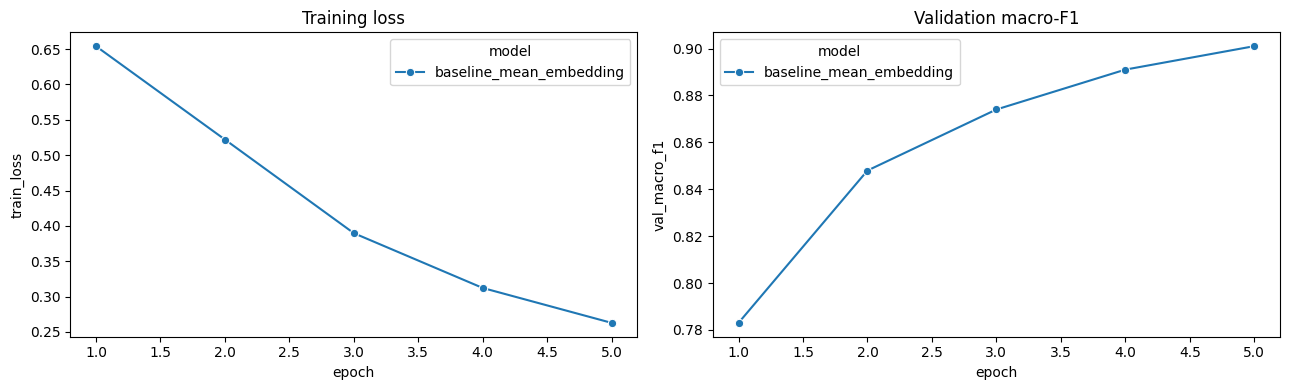

In [80]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.lineplot(data=history_df, x="epoch", y="train_loss", hue="model", marker="o", ax=ax[0])
sns.lineplot(data=history_df, x="epoch", y="val_macro_f1", hue="model", marker="o", ax=ax[1])
ax[0].set_title("Training loss"); ax[1].set_title("Validation macro-F1")
plt.tight_layout()


## 2.2.8 Accuracy, precision, recall, F1, calibration, and confidence intervals

In [81]:
def ece(y, p, bins=10):
    edges = np.linspace(0, 1, bins + 1); value = 0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (p >= lo) & (p <= hi if hi == 1 else p < hi)
        if mask.any(): value += mask.mean() * abs(p[mask].mean() - y[mask].mean())
    return float(value)

In [82]:
def bootstrap_ci(y, pred, metric, n=1000):
    rng = np.random.default_rng(SEED); vals = []
    for _ in range(n):
        ix = rng.integers(0, len(y), len(y)); vals.append(metric(y[ix], pred[ix]))
    return np.percentile(vals, [2.5, 97.5])

In [83]:
def ece(y, p, bins=10):
    edges = np.linspace(0, 1, bins + 1)
    value = 0.0
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (p >= lo) & (p <= hi if hi == 1 else p < hi)
        if mask.any():
            value += mask.mean() * abs(p[mask].mean() - y[mask].mean())
    return float(value)


def bootstrap_ci(y, pred, metric, n=1000):
    rng = np.random.default_rng(SEED)
    values = []
    for _ in range(n):
        indices = rng.integers(0, len(y), len(y))
        values.append(metric(y[indices], pred[indices]))
    return np.percentile(values, [2.5, 97.5])


def metrics(model_name, y, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)
    result = {
        "model": model_name,
        "decision_threshold": threshold,
        "accuracy": accuracy_score(y, predictions),
    }

    for average in ("macro", "micro", "weighted"):
        precision, recall, f1, _ = precision_recall_fscore_support(
            y, predictions, average=average, zero_division=0
        )
        result[f"precision_{average}"] = precision
        result[f"recall_{average}"] = recall
        result[f"f1_{average}"] = f1

    result.update({
        "roc_auc": roc_auc_score(y, probabilities),
        "pr_auc": average_precision_score(y, probabilities),
        "mcc": matthews_corrcoef(y, predictions),
        "brier_score": brier_score_loss(y, probabilities),
        "ece_10_bins": ece(y, probabilities),
    })
    result["accuracy_ci95"] = bootstrap_ci(y, predictions, accuracy_score)
    result["macro_f1_ci95"] = bootstrap_ci(
        y, predictions, lambda a, b: f1_score(a, b, average="macro", zero_division=0)
    )
    result["mcc_ci95"] = bootstrap_ci(y, predictions, matthews_corrcoef)
    return result


metric_df = pd.DataFrame([
    metrics(model_name, run["y"], run["p"], run["threshold"])
    for model_name, run in runs.items()
])
display(metric_df.round(4))
metric_df.to_csv(RUN_DIR / f"metrics_{name}.csv", index=False)
metric_df.to_csv(RUN_DIR / "metrics_report.csv", index=False)
resource_df.to_csv(RUN_DIR / f"resources_{name}.csv", index=False)
resource_df.to_csv(OUTPUT_DIR / f"resources_{name}.csv", index=False)

write_run_log("Metrics summary:")
write_run_log(metric_df.to_string(index=False))


,model,decision_threshold,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,recall_weighted,f1_weighted,roc_auc,pr_auc,mcc,brier_score,ece_10_bins,accuracy_ci95,macro_f1_ci95,mcc_ci95
0,baseline_mean_embedding,0.52,0.8912,0.8915,0.8912,0.8912,0.8912,0.8912,0.8912,0.8915,0.8912,0.8912,0.9567,0.9567,0.7827,0.0831,0.0541,"[0.882995, 0.8994]","[0.8829115517398681, 0.8993566625543431]","[0.7662536182563189, 0.7989381265162713]"


Metrics summary:
                  model  decision_threshold  accuracy  precision_macro  recall_macro  f1_macro  precision_micro  recall_micro  f1_micro  precision_weighted  recall_weighted  f1_weighted  roc_auc   pr_auc      mcc  brier_score  ece_10_bins      accuracy_ci95                            macro_f1_ci95                                 mcc_ci95
baseline_mean_embedding                0.52    0.8912         0.891525        0.8912  0.891177           0.8912        0.8912    0.8912            0.891525           0.8912     0.891177 0.956677 0.956691 0.782725     0.083145     0.054082 [0.882995, 0.8994] [0.8829115517398681, 0.8993566625543431] [0.7662536182563189, 0.7989381265162713]


Metrics were calculated and saved in the previous metrics cell.

The model-specific metrics CSV was saved in the `outputs/` folder.

## 2.2.9 Confusion matrices

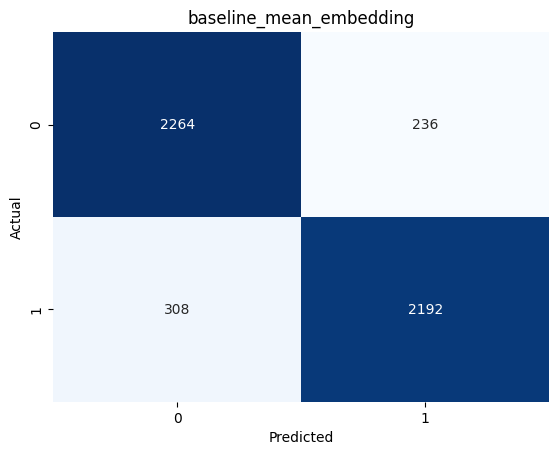

In [84]:
for name, run in runs.items():
    cm = confusion_matrix(run["y"], run["p"] >= run["threshold"])
    pd.DataFrame(cm, index=["actual_0", "actual_1"],
                 columns=["predicted_0", "predicted_1"]).to_csv(
        OUTPUT_DIR / f"confusion_matrix_{name}.csv")
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(name); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.show()

## 2.2.10 Paired McNemar test

This model-specific notebook cannot calculate a paired test by itself. The companion `compare_three_models.ipynb` loads the three saved prediction files and runs baseline vs. CNN and baseline vs. BiGRU McNemar tests.

## 2.2.11 Macro-F1 and error rate per robustness slice

In [85]:
slice_frame = test_df.copy()
slice_frame["word_count"] = slice_frame["tokens"].map(len)
slice_frame["length_slice"] = pd.cut(slice_frame["word_count"], [-1, 40, 100, np.inf],
    labels=["short", "medium", "long"])
slice_frame["negation_slice"] = slice_frame["text"].str.lower().str.contains(
    r"\b(not|never|no|n't)\b", regex=True)
slice_frame["punctuation_slice"] = np.where(
    slice_frame["text"].str.count(r"[!?]") >= 3, "high_punctuation", "low_punctuation")

/tmp/ipykernel_523/2957509712.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  slice_frame["negation_slice"] = slice_frame["text"].str.lower().str.contains(


In [86]:
def slice_results_for(model_name, run, frame, column):
    rows = []
    values = frame[column].dropna().unique()
    for value in values:
        mask = frame[column].to_numpy() == value
        predictions = (run["p"][mask] >= run["threshold"]).astype(int)
        rows.append({
            "model": model_name,
            "slice_type": column,
            "slice": str(value),
            "n": int(mask.sum()),
            "macro_f1": f1_score(
                run["y"][mask], predictions, average="macro", zero_division=0
            ),
            "error_rate": 1 - accuracy_score(run["y"][mask], predictions),
        })
    return rows


In [87]:
slice_rows = []
for model_name, run in runs.items():
    for column in ("length_slice", "negation_slice", "punctuation_slice"):
        slice_rows.extend(slice_results_for(model_name, run, slice_frame, column))

slice_df = pd.DataFrame(slice_rows)
display(slice_df)
slice_df.to_csv(OUTPUT_DIR / "robustness_slices_baseline_mean_embedding.csv", index=False)
slice_df.to_csv(RUN_DIR / "robustness_slices_baseline_mean_embedding.csv", index=False)
write_run_log("Robustness slices saved using each model's validation-selected threshold.")


,model,slice_type,slice,n,macro_f1,error_rate
0,baseline_mean_embedding,length_slice,long,1457,0.893517,0.102265
1,baseline_mean_embedding,length_slice,short,1622,0.885465,0.110974
2,baseline_mean_embedding,length_slice,medium,1921,0.887939,0.111921
3,baseline_mean_embedding,negation_slice,True,2956,0.876294,0.112991
4,baseline_mean_embedding,negation_slice,False,2044,0.878785,0.102740
5,baseline_mean_embedding,punctuation_slice,low_punctuation,3896,0.882883,0.117043
6,baseline_mean_embedding,punctuation_slice,high_punctuation,1104,0.920246,0.079710


Robustness slices saved using each model's validation-selected threshold.


## 2.2.12 Manual review of 20 model errors

Read the 20 selected rows and fill in manual_error_type and testable_fix. The initial bucket is a starting point; assign the final category after reviewing each example.

In [88]:
best_name = metric_df.sort_values("f1_macro", ascending=False).iloc[0]["model"]
best = runs[best_name]
review = test_df.iloc[best["ids"]].copy()
review["prob_positive"] = best["p"]; review["prediction"] = (best["p"] >= best["threshold"]).astype(int)
review["correct"] = review["prediction"].to_numpy() == review["label"].to_numpy()
review["confidence"] = np.abs(review["prob_positive"] - best["threshold"])
review["length_slice"] = pd.cut(review["tokens"].map(len), [-1,40,100,np.inf],
    labels=["short","medium","long"])
review["has_negation"] = review["text"].str.lower().str.contains(r"\b(not|never|no|n't)\b", regex=True)

/tmp/ipykernel_523/2890817078.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  review["has_negation"] = review["text"].str.lower().str.contains(r"\b(not|never|no|n't)\b", regex=True)


In [89]:
# Select four non-overlapping groups of five errors.
used = set()
def take_unique(pool, n=5):
    global used
    pool = pool.loc[~pool.index.isin(used)]
    chosen = pool.head(n)
    used.update(chosen.index.tolist())
    return chosen

fp = take_unique(review[(review.label==0) & (review.prediction==1)]
                 .sort_values("confidence", ascending=False))
fn = take_unique(review[(review.label==1) & (review.prediction==0)]
                 .sort_values("confidence", ascending=False))
near_pool = review[~review.correct].sort_values("confidence")
near = take_unique(near_pool)
slice_pool = review[~review.correct &
                    (review.has_negation | (review.length_slice == "long"))]
slc = take_unique(slice_pool.sort_values("confidence", ascending=False))
if len(slc) < 5:
    fallback = take_unique(review[~review.correct].sort_values("confidence", ascending=False),
                           5 - len(slc))
    slc = pd.concat([slc, fallback])
assert len(fp) == len(fn) == len(near) == len(slc) == 5
assert len(used) == 20, "The final manual review must contain 20 unique rows."

In [90]:
def review_rows(frame, bucket):
    x = frame.copy(); x["review_bucket"] = bucket
    x["manual_error_type"] = ""; x["testable_fix"] = ""
    return x[["review_bucket","text","label","prob_positive","prediction",
              "length_slice","has_negation","manual_error_type","testable_fix"]]

In [91]:
error_review = pd.concat([review_rows(fp, "confident_false_positive"),
    review_rows(fn, "confident_false_negative"), review_rows(near, "near_threshold"),
    review_rows(slc, "slice_specific")], ignore_index=True)
assert len(error_review) == 20
write_run_log(f"Selected {len(error_review)} unique errors for {best_name}.")
display(error_review)
error_review.to_csv(OUTPUT_DIR / f"manual_error_review_{best_name}.csv", index=False)

Selected 20 unique errors for baseline_mean_embedding.


,review_bucket,text,label,prob_positive,prediction,length_slice,has_negation,manual_error_type,testable_fix
0,confident_false_positive,of all the buffets I had in Vegas this was my ...,0,0.997897,1,short,False,,
1,confident_false_positive,Large variety,0,0.996980,1,short,False,,
2,confident_false_positive,Good location and friendly staff. But need add...,0,0.992823,1,short,False,,
3,confident_false_positive,20 years for me and sad to see them go. Sadde...,0,0.988589,1,medium,True,,
4,confident_false_positive,It is CLOSED!!! We loved the place. It was t...,0,0.982861,1,short,False,,
5,confident_false_negative,Decent!,1,0.000268,0,short,False,,
6,confident_false_negative,Good but it could be better,1,0.004060,0,short,False,,
7,confident_false_negative,I think the problem here is management. Enough...,1,0.010836,0,short,False,,
8,confident_false_negative,I was informed by the cook/owner that they no ...,1,0.017556,0,short,True,,
9,confident_false_negative,Outstanding food quality and customer service ...,1,0.017929,0,short,False,,


## 2.3 Comparative Analysis and Observations

In [92]:
final_comparison = metric_df[["model","accuracy","f1_macro","f1_micro","f1_weighted",
    "roc_auc","pr_auc","mcc","brier_score","ece_10_bins"]].merge(resource_df, on="model")
display(final_comparison.sort_values("f1_macro", ascending=False).round(4))


,model,accuracy,f1_macro,f1_micro,f1_weighted,roc_auc,pr_auc,mcc,brier_score,ece_10_bins,parameters,training_seconds,examples_per_second,peak_memory_mb,device,device_name,decision_threshold
0,baseline_mean_embedding,0.8912,0.8912,0.8912,0.8912,0.9567,0.9567,0.7827,0.0831,0.0541,3840129,33.703,2670.3887,6182.0977,cpu,x86_64,0.52


Use the tables above to write the discussion in `METRICS.md` after the run.

- Compare macro-F1, MCC, ROC-AUC, PR-AUC, calibration, and 95% bootstrap intervals.
- Explain whether the CNN helps local phrase patterns and whether the BiGRU helps sequence context.
- Identify the weakest length, negation, and punctuation slices.
- Compare accuracy, training time, examples/sec, parameter count, and peak memory.
- Treat this as a deliberately small baseline: sample cap, two epochs, stemming, stopword removal, and a fixed 0.5 threshold are limitations.
- Propose testable improvements: preserve more context, tune the threshold on validation data, use subwords, train longer, increase the sample, and compare against a second dataset.

Important preprocessing decision: `not`, `never`, and `no` are retained because removing negation can reverse sentiment meaning.

## Final saved files

After execution, inspect `RUN_LOG.txt`, `outputs/`, and `checkpoints/` before submission.

## Automatic Markdown metrics report

The next cell writes `metrics.md` from the actual run values.

In [93]:
# Write the Markdown metrics report from this run.
def _fmt(value):
    if isinstance(value, (float, np.floating)):
        return f"{float(value):.4f}"
    if isinstance(value, np.ndarray):
        return "[" + ", ".join(f"{float(x):.4f}" for x in value) + "]"
    return str(value)

row = metric_df.iloc[0].to_dict()
resource = resource_df.iloc[0].to_dict()
cm = confusion_matrix(runs[name]["y"], runs[name]["p"] >= runs[name]["threshold"])
report_lines = [
    f"# Task 2 Metrics — {name}",
    "",
    f"Report date: `{time.strftime('%Y-%m-%d %H:%M:%S')}`",
    "",
    "This report records values from the current notebook run. "
    "The embedding was learned from scratch; no pretrained embeddings or language model were used.",
    "",
    "## Architecture and run configuration",
    "",
    f"- Model: `{name}`",
    f"- Dataset: Yelp Polarity (`fancyzhx/yelp_polarity`)",
    f"- Training rows: `{len(train_df)}`; validation rows: `{len(val_df)}`; test rows: `{len(test_df)}`",
    f"- Seed: `{SEED}`; vocabulary: `{len(stoi)}`; maximum length: `{MAX_LEN}`",
    f"- Epochs: `{EPOCHS}`; batch size: `{BATCH_SIZE}`; learning rate: `{LEARNING_RATE}`; weight decay: `{WEIGHT_DECAY}`",
    f"- Decision threshold selected on validation data: `{_fmt(row['decision_threshold'])}`",
    "",
    "## Classification and calibration metrics",
    "",
    "| Metric | Value |",
    "|---|---:|",
]
metric_keys = [
    "accuracy", "precision_macro", "recall_macro", "f1_macro",
    "precision_micro", "recall_micro", "f1_micro", "precision_weighted",
    "recall_weighted", "f1_weighted", "roc_auc", "pr_auc", "mcc",
    "brier_score", "ece_10_bins", "accuracy_ci95", "macro_f1_ci95", "mcc_ci95",
]
for key in metric_keys:
    report_lines.append(f"| `{key}` | `{_fmt(row.get(key, 'not available'))}` |")
report_lines += [
    "",
    "## Confusion matrix",
    "",
    "Rows are actual labels and columns are predicted labels.",
    "",
    "```text",
    str(cm),
    "```",
    "",
    "## Training resources",
    "",
    "| Resource | Value |",
    "|---|---:|",
]
for key in ["parameters", "training_seconds", "examples_per_second", "peak_memory_mb", "device", "device_name"]:
    report_lines.append(f"| `{key}` | `{_fmt(resource.get(key, 'not available'))}` |")
report_lines += [
    "",
    "## Saved evidence",
    "",
    f"- Raw log: `RUN_LOG.txt`",
    f"- Metrics CSV: `metrics_{name}.csv`",
    f"- Checkpoint: `checkpoints/{name}.pt`",
    f"- Predictions: `outputs/predictions_{name}.csv`",
    f"- Robustness slices: `outputs/robustness_slices_{name}.csv`",
    f"- Confusion matrix: `outputs/confusion_matrix_{name}.csv`",
    "",
    "## Interpretation",
    "",
    f"The validation-selected threshold was {_fmt(row['decision_threshold'])}. "
    "Use the confidence intervals and the robustness-slice CSV when discussing uncertainty and failure patterns. "
    "The 20 selected rows in the manual-review CSV still require human labels for error type and testable fix.",
]
(RUN_DIR / "metrics.md").write_text("\n".join(report_lines) + "\n", encoding="utf-8")
write_run_log(f"Wrote metrics Markdown: {RUN_DIR / 'metrics.md'}")


Wrote metrics Markdown: /content/sample_data/TASK2_RUN_DIR/mean_embedding/metrics.md


In [94]:
# Save the member-level reports and verify the evidence files.
results_text = f"""# Model Results

## Model

- Model name: `baseline_mean_embedding`
- Dataset: Yelp Polarity
- Device: `{resource_df.iloc[0]['device_name']}`
- Parameters: `{int(resource_df.iloc[0]['parameters'])}`
- Training time (seconds): `{resource_df.iloc[0]['training_seconds']:.4f}`
- Examples per second: `{resource_df.iloc[0]['examples_per_second']:.2f}`
- Decision threshold: `{metric_df.iloc[0]['decision_threshold']:.4f}`

## Main results

| Metric | Value |
|---|---:|
| Accuracy | {metric_df.iloc[0]['accuracy']:.4f} |
| Macro-F1 | {metric_df.iloc[0]['f1_macro']:.4f} |
| ROC-AUC | {metric_df.iloc[0]['roc_auc']:.4f} |
| PR-AUC | {metric_df.iloc[0]['pr_auc']:.4f} |
| MCC | {metric_df.iloc[0]['mcc']:.4f} |
| Brier score | {metric_df.iloc[0]['brier_score']:.4f} |
| ECE | {metric_df.iloc[0]['ece_10_bins']:.4f} |

The complete metric table is stored in `metrics_report.csv`.
"""
RESULTS_PATH.write_text(results_text, encoding="utf-8")

failure_text = """# Failure Analysis

The exported file `outputs/manual_error_review_baseline_mean_embedding.csv` contains 20 unique review rows:

- 5 confident false positives
- 5 confident false negatives
- 5 near-threshold errors
- 5 slice-specific failures

Review the text and complete the `manual_error_type` and `testable_fix` columns before submission.
"""
FAILURE_ANALYSIS_PATH.write_text(failure_text, encoding="utf-8")

write_run_log(f"Member structure: {RUN_DIR}")
write_run_log(f"Results report: {RESULTS_PATH}")
write_run_log(f"Failure analysis: {FAILURE_ANALYSIS_PATH}")
write_run_log(f"Completed {name} at {time.strftime('%Y-%m-%d %H:%M:%S')}")
write_run_log(f"Log file: {RUN_LOG_PATH.resolve()}")
write_run_log(f"Log size: {RUN_LOG_PATH.stat().st_size} bytes")


Member structure: /content/sample_data/TASK2_RUN_DIR/mean_embedding
Results report: /content/sample_data/TASK2_RUN_DIR/mean_embedding/results.md
Failure analysis: /content/sample_data/TASK2_RUN_DIR/mean_embedding/failure_analysis.md
Completed baseline_mean_embedding at 2026-10-03 20:14:29
Log file: /content/sample_data/TASK2_RUN_DIR/mean_embedding/RUN_LOG.txt
Log size: 3581 bytes
